<a href="https://colab.research.google.com/github/Amruth-U-tech/DL-Journey/blob/main/06-NLP/NLP_Apllication-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences #for padding sequense because there can be diff length of words in diff tokens padding adds zero to make all length same
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense #embedding is to convert the text into no.s or vectors for machine to understand
import matplotlib.pyplot as plt

**loding data**

In [3]:
path = tf.keras.utils.get_file("shakespeare.txt","https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")
text = open(path).read().lower()[:200000] #we open read it in lower case (becuase there can be uniform encoding for letters)  and read upto 200k words

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**tokenizeing**

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
total_words

4900

**creating sequences**

we are using N-Gram sequence technique

In [6]:
input_sequence = []
for line in text.split("\n"):
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    input_sequence.append(token_list[:i+1])
input_sequence

[[39, 82],
 [113, 25],
 [113, 25, 557],
 [113, 25, 557, 193],
 [113, 25, 557, 193, 275],
 [113, 25, 557, 193, 275, 99],
 [113, 25, 557, 193, 275, 99, 23],
 [113, 25, 557, 193, 275, 99, 23, 100],
 [100, 100],
 [39, 82],
 [4, 28],
 [4, 28, 32],
 [4, 28, 32, 717],
 [4, 28, 32, 717, 196],
 [4, 28, 32, 717, 196, 3],
 [4, 28, 32, 717, 196, 3, 276],
 [4, 28, 32, 717, 196, 3, 276, 47],
 [4, 28, 32, 717, 196, 3, 276, 47, 3],
 [4, 28, 32, 717, 196, 3, 276, 47, 3, 1406],
 [717, 717],
 [39, 82],
 [39, 4],
 [39, 4, 94],
 [39, 4, 94, 277],
 [39, 4, 94, 277, 48],
 [39, 4, 94, 277, 48, 20],
 [39, 4, 94, 277, 48, 20, 1407],
 [39, 4, 94, 277, 48, 20, 1407, 298],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3, 1],
 [39, 4, 94, 277, 48, 20, 1407, 298, 3, 1, 87],
 [25, 1054],
 [25, 1054, 25],
 [25, 1054, 25, 1054],
 [39, 82],
 [73, 55],
 [73, 55, 299],
 [73, 55, 299, 19],
 [73, 55, 299, 19, 2],
 [73, 55, 299, 19, 2, 313],
 [73, 55, 299, 19, 2, 313, 14],
 [73, 55, 299, 19, 2

**padding and labels**

In [7]:
max_len = max(len(seq) for seq in input_sequence)
input_sequence = pad_sequences(input_sequence,maxlen=max_len,padding="pre")
print("totale no. o f inpiut sequences:",len(input_sequence))
print("maximum length of input sequences:",max_len)
input_sequence

totale no. o f inpiut sequences: 29966
maximum length of input sequences: 13


array([[   0,    0,    0, ...,    0,   39,   82],
       [   0,    0,    0, ...,    0,  113,   25],
       [   0,    0,    0, ...,  113,   25,  557],
       ...,
       [   0,    0,    0, ...,   17,    9,   31],
       [   0,    0,    0, ...,    9,   31,  362],
       [   0,    0,    0, ...,   31,  362, 1369]], dtype=int32)

In [9]:
x  = input_sequence[:,:-1]
y = tf.keras.utils.to_categorical(input_sequence[:,-1],num_classes=total_words) #makeing it categorical because the can be classes to predict a word from the vocab using softmax
#4900 categories
print(f"total no. of sequnces = {len(input_sequence)}, vocab size = {total_words}")
x.shape, y.shape

total no. of sequnces = 29966, vocab size = 4900


((29966, 12), (29966, 4900))

**building the rnn model to train**

note because thsi is text data ther is one extra layer to be added before training to convert it to vectors just as flatten for cnn models

In [11]:
model = Sequential()
model.add(Embedding(total_words,100,input_length=max_len-1)) #we craete a dence vector of len = 100
model.add(SimpleRNN(128))
model.add(Dense(total_words,activation="softmax"))

model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(x,y,epochs=50,batch_size=128,validation_split=0.1)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.0349 - loss: 6.9118 - val_accuracy: 0.0357 - val_loss: 6.9319
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.0470 - loss: 6.4243 - val_accuracy: 0.0450 - val_loss: 6.9125
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.0597 - loss: 6.1525 - val_accuracy: 0.0557 - val_loss: 6.8710
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.0775 - loss: 5.8770 - val_accuracy: 0.0581 - val_loss: 6.8786
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.0896 - loss: 5.6231 - val_accuracy: 0.0691 - val_loss: 6.9195
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.1026 - loss: 5.3835 - val_accuracy: 0.0717 - val_loss: 6.9766
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.1145 - loss: 5.1546 - val_accuracy: 0.0684 - val_loss: 7.0442
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.1270 - loss: 4.9399 - 

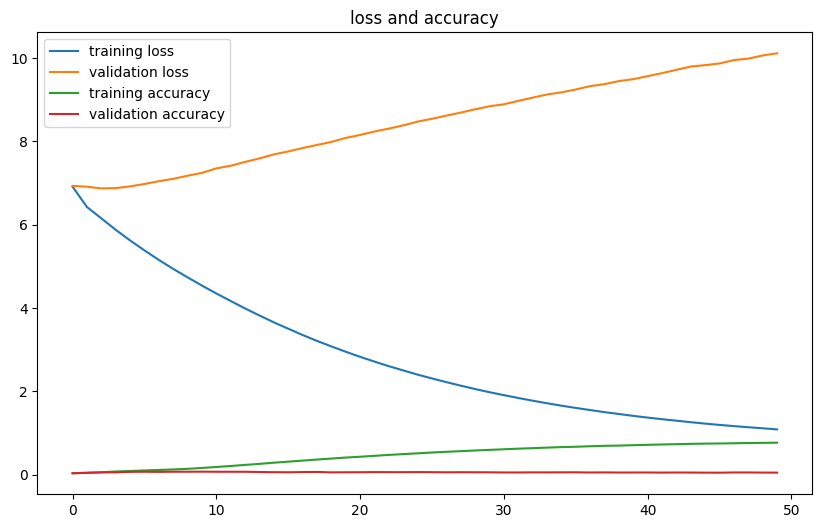

In [13]:
from prompt_toolkit.shortcuts.progress_bar import Label
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"],label="training loss")
plt.plot(history.history["val_loss"],label="validation loss")
plt.plot(history.history["accuracy"],label="training accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.title("loss and accuracy")
plt.legend()
plt.show()

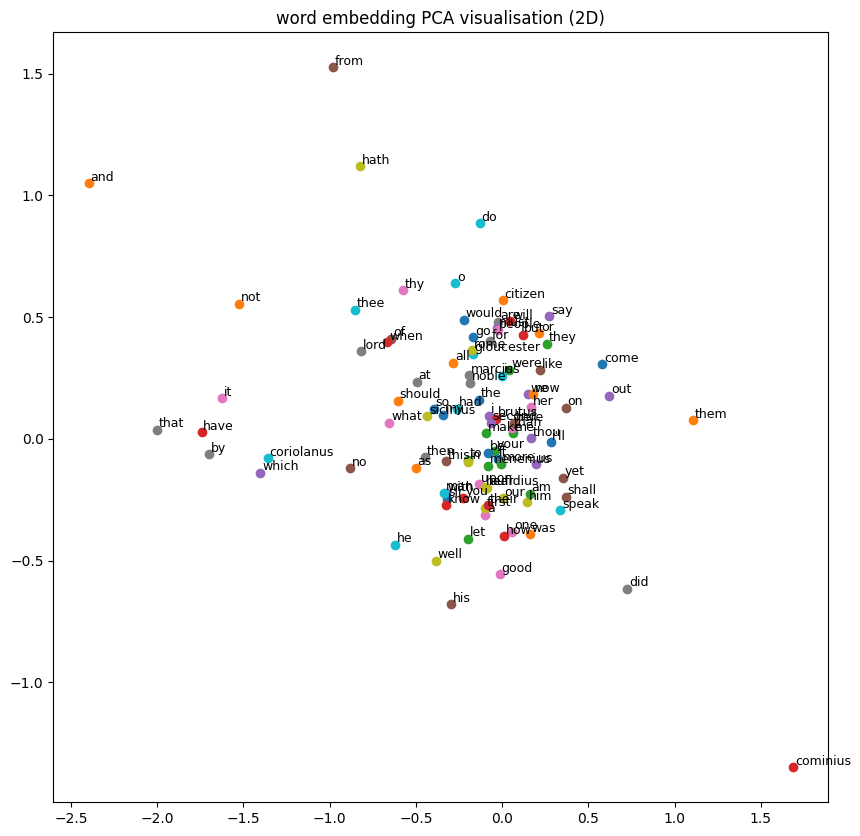

In [14]:
from sklearn.decomposition import PCA

embeddings = model.layers[0].get_weights()[0] #embedding layer weights

#reducing dimensions
pcs = PCA(n_components=2)
embeddings_2D = pcs.fit_transform(embeddings)

#plot first 100 words
plt.figure(figsize=(10,10))
for i,word in enumerate(list(tokenizer.word_index.keys())[:100]):
  x_new,y_new = embeddings_2D[i]
  plt.scatter(x_new,y_new)
  plt.text(x_new+0.01,y_new+0.01,word,fontsize=9)
plt.title("word embedding PCA visualisation (2D)")
plt.show()

**next word prediction function**

In [15]:
def predict_next_word(seed_text,n_words=5):
  results = seed_text
  for _ in range(n_words):
    seq = tokenizer.texts_to_sequences([results])[0]
    seq = pad_sequences([seq],maxlen=max_len-1,padding="pre")
    pred = model.predict(seq, verbose=0)[0]
    pred_index = np.argmax(pred)

    for word,index in tokenizer.word_index.items():
      if index == pred_index:
        results += " " + word
        break
  return results

In [16]:
seed = "this is the nobel of the"
print(predict_next_word(seed))

this is the nobel of the people's name is first way
